# Customer Churn Prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [2]:
df = pd.read_csv('Data/netflix_customer_churn.csv')
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churn
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,Gift Card,1,0.49,Action,1
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,Gift Card,5,0.03,Sci-Fi,1
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,Crypto,2,1.48,Drama,0
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,Crypto,2,0.35,Horror,1
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,Crypto,2,0.13,Action,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   payment_method          5000 non-null   object 
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   object 
 13  churn                   5000 non-null   int64  
dtypes: float64(3), int64(4), object(7)
memor

In [4]:
df.isna().sum().rename('missing_count').to_frame()

,missing_count
customer_id,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
payment_method,0


In [5]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,43.85,15.50,18.00,30.00,44.00,58.00,70.00
watch_hours,5000.0,11.65,12.01,0.01,3.34,8.00,16.03,110.40
last_login_days,5000.0,30.09,17.54,0.00,15.00,30.00,45.00,60.00
monthly_fee,5000.0,13.68,3.69,8.99,8.99,13.99,17.99,17.99
number_of_profiles,5000.0,3.02,1.42,1.00,2.00,3.00,4.00,5.00
avg_watch_time_per_day,5000.0,0.87,2.62,0.00,0.11,0.29,0.72,98.42
churn,5000.0,0.50,0.50,0.00,0.00,1.00,1.00,1.00


## Exploratory Data Analysis (EDA)

In [6]:
df['churn'].value_counts(dropna=True).to_frame('count')

,count
churn,
1,2515
0,2485


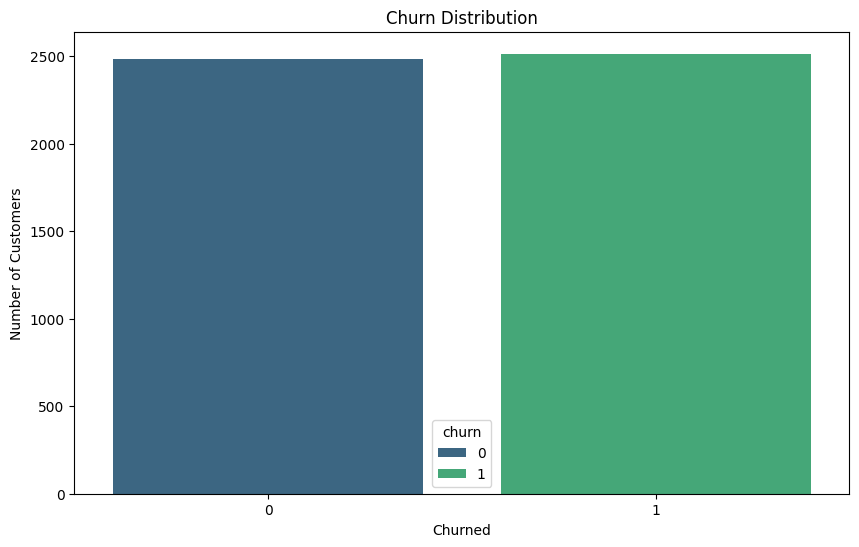

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='churn', hue='churn', palette='viridis')
plt.title("Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")
plt.savefig('Visualizations/churn_distribution.png')
plt.show()

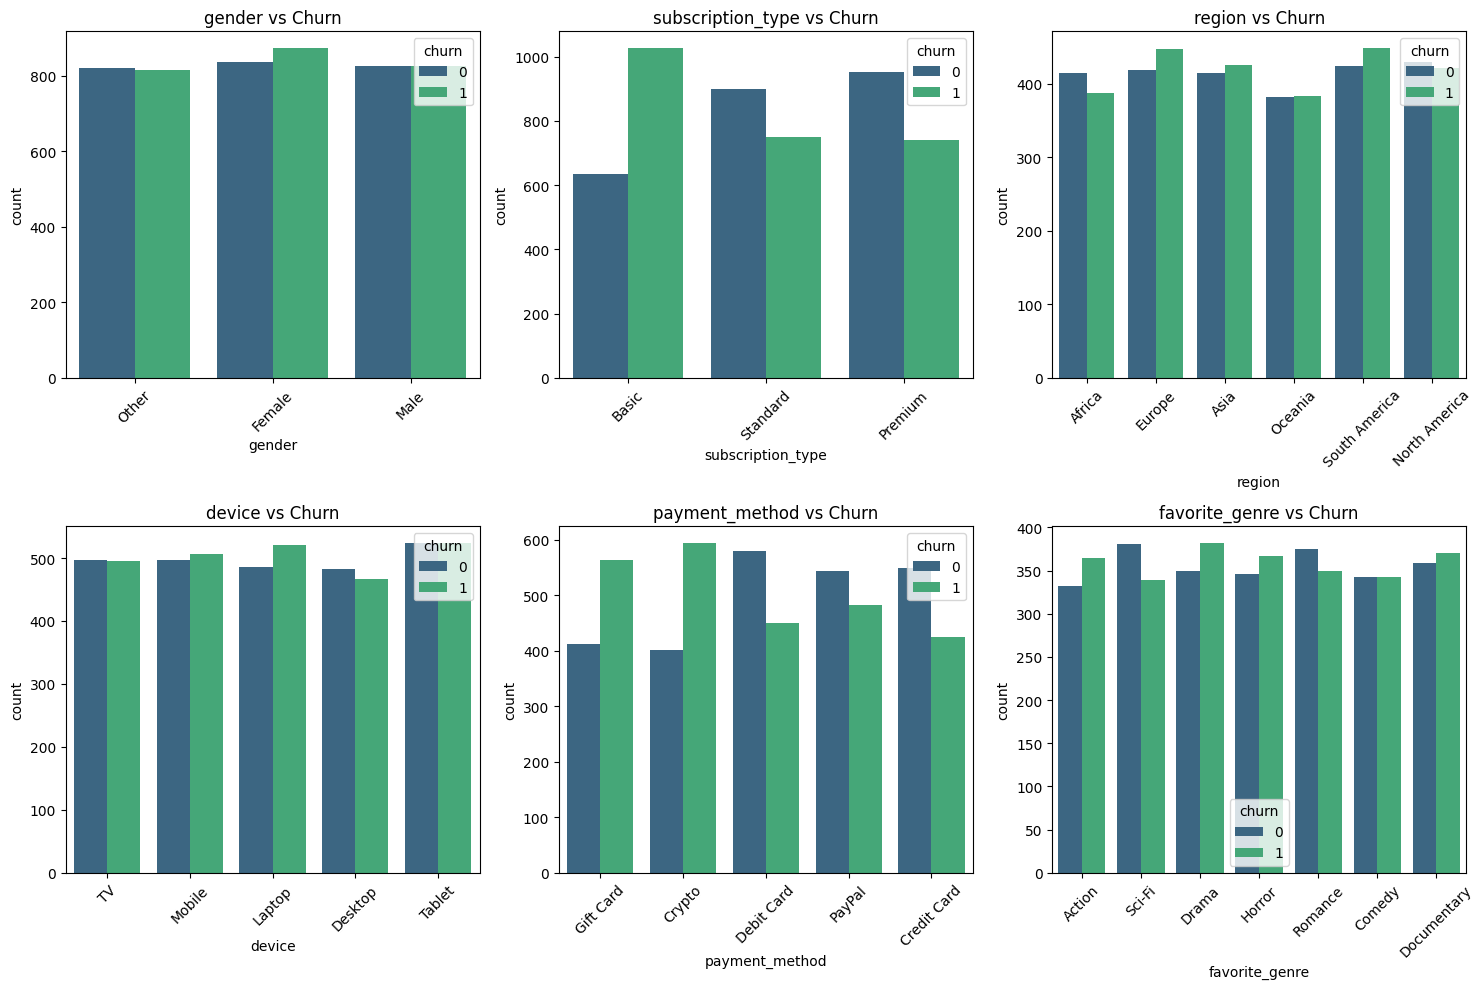

In [8]:
cat_cols = ['gender', 'subscription_type', 'region', 'device', 'payment_method','favorite_genre']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, hue='churn', palette='viridis')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Visualizations/categorical_features.png')
plt.show()

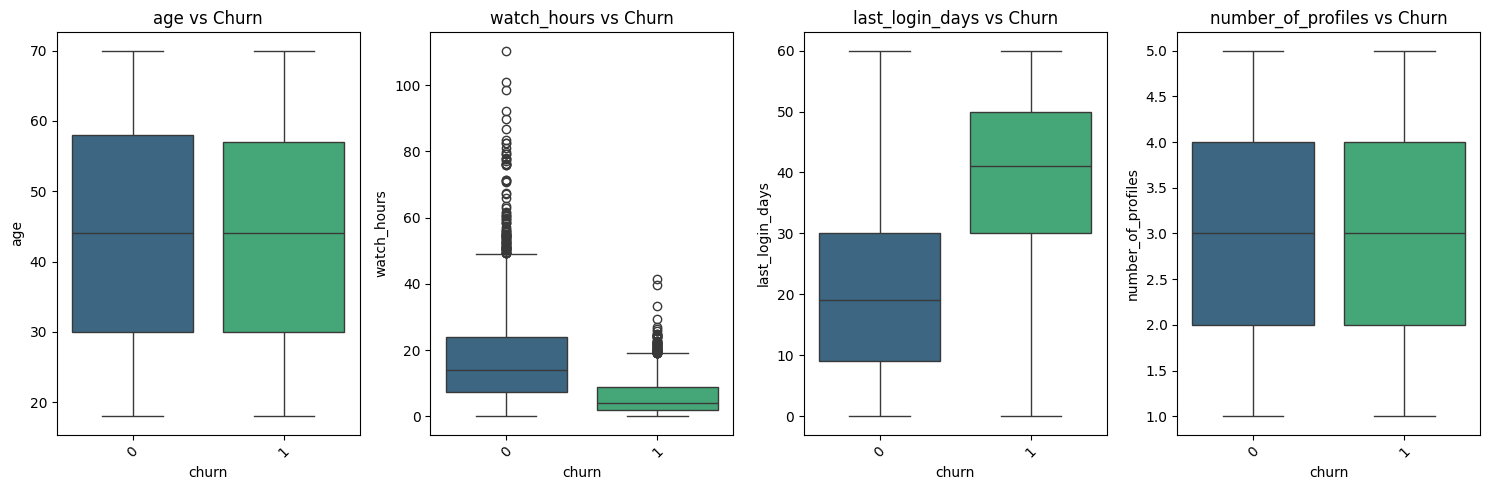

In [9]:
num_cols = ['age', 'watch_hours', 'last_login_days', 'number_of_profiles']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(data=df, x='churn', y=col, palette='viridis')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Visualizations/numerical_features.png')
plt.show()